In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


Data Cleaning

In [74]:
#loading the dataset
df = pd.read_csv(r"datasets\all_cars.csv")

C:\Users\joshi\AppData\Local\Temp\ipykernel_40572\107190959.py:2: DtypeWarning: Columns (0: Dual-Clutch Automatic Transmission) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"datasets\all_cars.csv")


In [75]:
#basic EDA
print(df.head())
print(df.info())
print(df.isnull().sum())

   make  model  year bodytype                             trim   price  \
0  Ford  F-150  2001  Default       F150 Regular Cab Short Bed  3450.0   
1  Ford  F-150  2001  Default        F150 Regular Cab Long Bed  3500.0   
2  Ford  F-150  2001  Default      F150 Super Cab Short Bed 4D  4500.0   
3  Ford  F-150  2001  Default       F150 Super Cab Long Bed 4D  4550.0   
4  Ford  F-150  2001  Default  F150 SuperCrew Cab Short Bed 4D  6025.0   

   mpg_city  mpg_hwy  mpg_comb Fuel Type  ...  Cup Holder Count Alloy Wheels  \
0       NaN      NaN       NaN       Gas  ...               NaN     Optional   
1      14.0     19.0      16.0       Gas  ...               NaN     Optional   
2      14.0     19.0      16.0       Gas  ...               NaN     Optional   
3      14.0     19.0      16.0       Gas  ...               NaN     Optional   
4      14.0     17.0      15.0       Gas  ...               NaN     Standard   

   Fog Lights  Power Folding Exterior Mirrors Rear Spoiler  \
0         Na

In [76]:
#standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [77]:
# rename columns to for new dataset
df = df.rename(columns={
    "make": "brand",
    "year": "model_year",
    "fuel_type": "fuel_type",
})

In [78]:
#step 3: convert numeric columns
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["model_year"] = pd.to_numeric(df["model_year"], errors="coerce")
df["hp"] = pd.to_numeric(df["hp"], errors="coerce")

In [79]:
#make price look good
# Clean price
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
#check clean price
print(df["price"].head())

0    3450.0
1    3500.0
2    4500.0
3    4550.0
4    6025.0
Name: price, dtype: float64


In [80]:
#drop rows with missing values in critical columns
df = df.dropna(subset=["brand", "model_year", "hp", "fuel_type", "price"])

In [81]:
#filter out outliers in price
df = df[(df["price"] >= 3000) & (df["price"] <= 200000)]

In [82]:
print("\nCleaned data preview:")
print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())



Cleaned data preview:
  brand  model  model_year bodytype                             trim   price  \
0  Ford  F-150        2001  Default       F150 Regular Cab Short Bed  3450.0   
1  Ford  F-150        2001  Default        F150 Regular Cab Long Bed  3500.0   
2  Ford  F-150        2001  Default      F150 Super Cab Short Bed 4D  4500.0   
3  Ford  F-150        2001  Default       F150 Super Cab Long Bed 4D  4550.0   
4  Ford  F-150        2001  Default  F150 SuperCrew Cab Short Bed 4D  6025.0   

   mpg_city  mpg_hwy  mpg_comb fuel_type  ...  cup_holder_count alloy_wheels  \
0       NaN      NaN       NaN       Gas  ...               NaN     Optional   
1      14.0     19.0      16.0       Gas  ...               NaN     Optional   
2      14.0     19.0      16.0       Gas  ...               NaN     Optional   
3      14.0     19.0      16.0       Gas  ...               NaN     Optional   
4      14.0     17.0      15.0       Gas  ...               NaN     Standard   

   fog_lights  

Separate Data For Main Question and Side Questions

In [83]:
# Main Question
# To what extent can machine learning models use vehicle attributes (horsepower, model year, fuel type, brand) to accurately predict new car prices?

main_features = [
    "brand",
    "model_year",
    "hp",
    "fuel_type"
]

df_main = df[main_features + ["price"]].dropna().copy()

In [84]:
# SIDE QUESTION 1: How does horsepower affect price?
df_hp = df[["hp", "price", "model_year", "brand"]].dropna(subset=["hp", "price"]).copy()

In [85]:
# SIDE QUESTION 2: How much does model year affect price?
df_year = df[["model_year","price", "brand"]].dropna(subset=["model_year", "price"]).copy()

In [86]:
# SIDE QUESTION 3: How does brand affect price?
df_brand = df[["brand", "price", "model_year", "hp"]].dropna(subset=["brand", "price"]).copy()

In [87]:
# SIDE QUESTION 4: How does fuel type affect price?
df_fuel = df[["fuel_type", "price", "model_year", "brand"]].dropna(subset=["fuel_type", "price"]).copy()

In [88]:
# SIDE QUESTION 5: What is the most important factor?
df_importance = df_main.copy()

In [89]:
#check dataset shapes
print("\nMain dataset shape:", df_main.shape)
print("Horsepower dataset shape:", df_hp.shape)
print("Model year dataset shape:", df_year.shape)
print("Brand dataset shape:", df_brand.shape)
print("Fuel type dataset shape:", df_fuel.shape)
print("Feature importance dataset shape:", df_importance.shape)


Main dataset shape: (23493, 5)
Horsepower dataset shape: (23493, 4)
Model year dataset shape: (23493, 3)
Brand dataset shape: (23493, 4)
Fuel type dataset shape: (23493, 4)
Feature importance dataset shape: (23493, 5)


Main Modeling Data

In [90]:
# prepare data for modeling
X = df_main[main_features]
y = df_main["price"]

#set up preprocessing
numeric_features = ["model_year", "hp"]
categorical_features = ["brand","fuel_type"]

# numeric transformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical transformer
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
# combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Evaluation Model

In [91]:
results = []
#evaluate models
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Calculate metrics
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # Print results
    print(f"\n=== {name} ===")
    print(f"R²: {r2:.4f}")
    print(f"MAE: ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    # Store results
    return {
        "model": name,
        "r2": r2,
        "mae": mae,
        "rmse": rmse
    }


Model 1: Linear Regression

In [92]:
# Linear Regression
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
#evaluate linear regression
results.append(
    evaluate_model("Linear Regression", lr_model, X_train, X_test, y_train, y_test)
)


=== Linear Regression ===
R²: 0.6891
MAE: $6,076.80
RMSE: $10,176.45


Model 2: Random Forest

In [93]:
# Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        #modify hyperparameters for better performance
        n_estimators=300,    
        max_features="sqrt",  
        random_state=42,
        n_jobs=-1
    ))
])
#evaluate random forest
results.append(
    evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test)
)


=== Random Forest ===
R²: 0.9102
MAE: $2,681.89
RMSE: $5,470.98


Model 3: Gradient Boosting

In [94]:
# Gradient Boosting
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", GradientBoostingRegressor(
        #modify hyperparameters for better performance
        random_state=42,n_estimators=400,))
])
#evaluate gradient boosting
results.append(
    evaluate_model("Gradient Boosting", gb_model, X_train, X_test, y_train, y_test)
)


=== Gradient Boosting ===
R²: 0.8772
MAE: $3,371.31
RMSE: $6,394.93


Model Comparsion and Other Tables

In [95]:
# Compare results
results_df = pd.DataFrame(results).sort_values(by="mae")
print("\nModel comparison:")
print(results_df)


Model comparison:
               model        r2          mae          rmse
1      Random Forest  0.910153  2681.887654   5470.979200
2  Gradient Boosting  0.877243  3371.310007   6394.929432
0  Linear Regression  0.689139  6076.801678  10176.448661


Side Question Visualizations

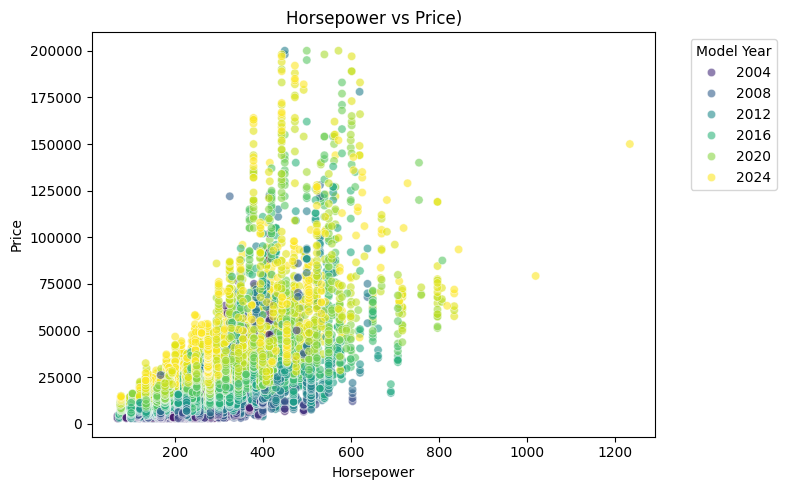

In [96]:
# --- Side Question 1: Horsepower vs Price ---
# Create scatter plot of horsepower vs price colored by model year
plt.figure(figsize=(8, 5))
palette = "viridis"  
sns.scatterplot(data=df_hp, x="hp", y="price", hue="model_year", palette=palette, alpha=0.6)
plt.title("Horsepower vs Price)")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.legend(title="Model Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

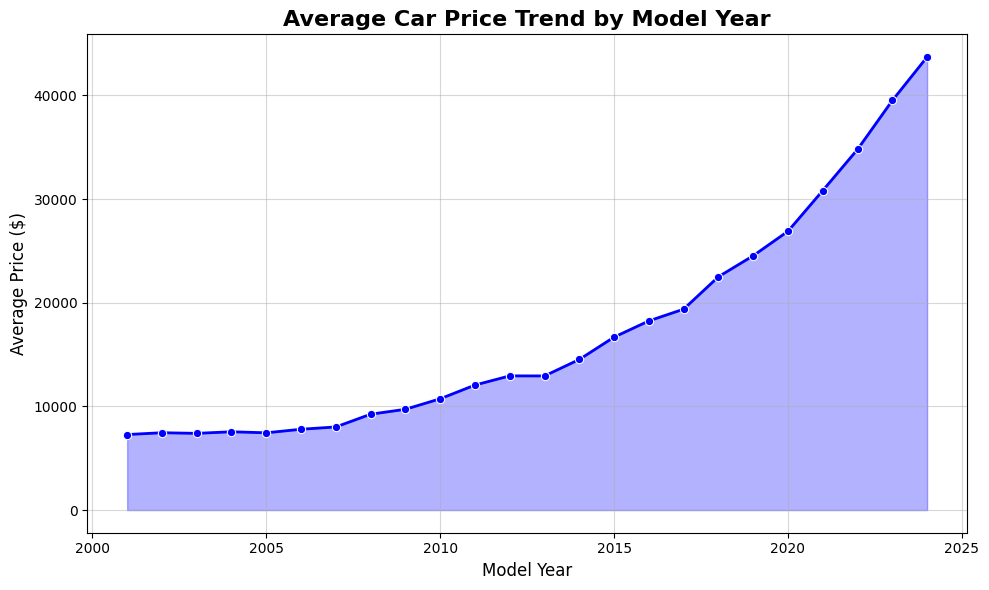

In [97]:
# --- SIDE QUESTION 2: Model Year vs Price ---

# Group by model_year and calculate average price
avg_price_by_year = df_year.groupby('model_year')['price'].mean().reset_index()
# Create line plot of average price by model year
plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_price_by_year, x='model_year', y='price', marker='o', color='blue', linewidth=2)
# Add shaded area under the line
plt.fill_between(avg_price_by_year['model_year'], avg_price_by_year['price'], alpha=0.3, color='blue')

#create title and labels
plt.title('Average Car Price Trend by Model Year', fontsize=16, fontweight='bold')
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_40572\2261382170.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


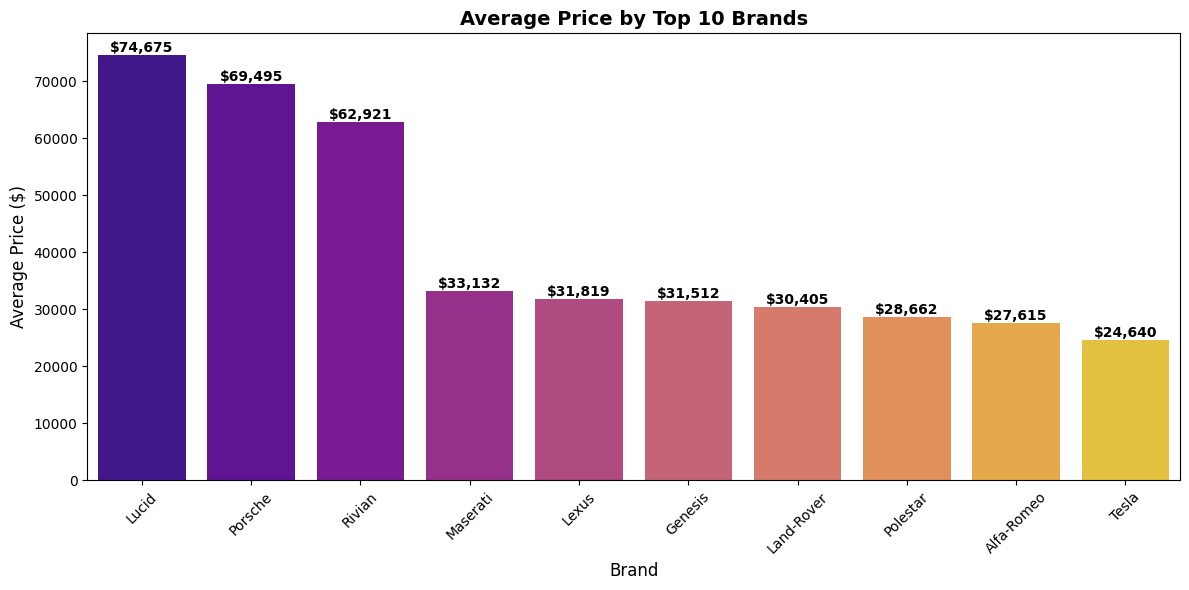

In [98]:
# --- Side Question 3: Brand vs Price ---
plt.figure(figsize=(12, 6))
# Calculate average price by brand and sort
avg_price_by_brand = (
    df_brand.groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
# Create bar plot of average price by brand
bar_plot = sns.barplot(
    x=avg_price_by_brand.index,
    y=avg_price_by_brand.values,
    palette="plasma"
)
# Add value labels on bars
for bar, value in zip(bar_plot.patches, avg_price_by_brand.values):
    bar_plot.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )
# Add title and labels
plt.xticks(rotation=45)
plt.title("Average Price by Top 10 Brands", fontsize=14, fontweight="bold")
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.tight_layout()
plt.show()

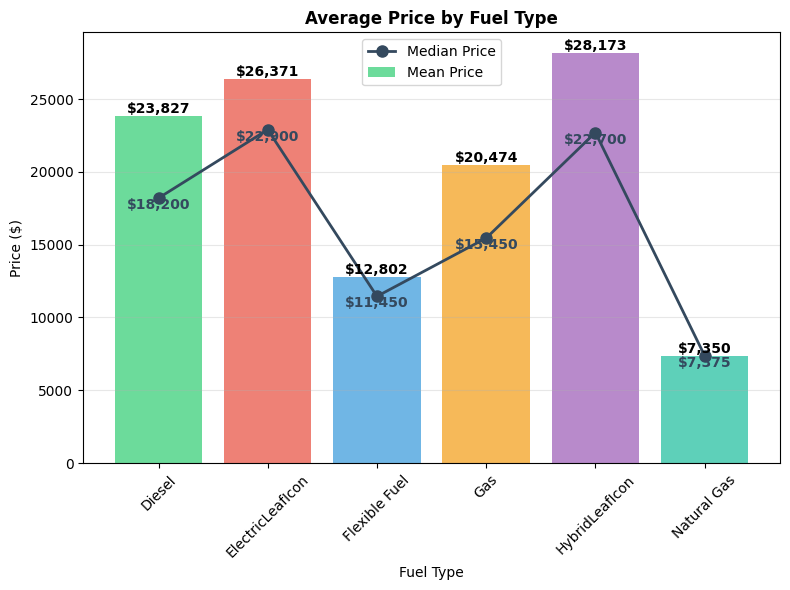

In [99]:
# --- Side Question 4: Fuel Type vs Price ---
fig, ax = plt.subplots(figsize=(8, 6))

# Summary statistics
fuel_stats = df_fuel.groupby("fuel_type")["price"].agg(["mean", "median", "count"])
x_pos = list(range(len(fuel_stats)))

# Bar plot for mean price
bars = ax.bar(
    x_pos,
    fuel_stats["mean"],
    color=["#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6", "#1abc9c"],
    alpha=0.7,
    label="Mean Price"
)

# Line plot for median price
ax.plot(
    x_pos,
    fuel_stats["median"],
    "o-",
    color="#34495e",
    linewidth=2,
    markersize=8,
    label="Median Price"
)

# Add value labels on bars
for bar, mean_val in zip(bars, fuel_stats["mean"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean_val,
        f'${mean_val:,.0f}',
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# Add value labels on line points
for i, median_val in enumerate(fuel_stats["median"]):
    ax.text(
        x_pos[i],
        median_val,
        f'${median_val:,.0f}',
        ha="center",
        va="top",
        fontweight="bold",
        color="#34495e"
    )
# Set title, labels, and grid
ax.set_title("Average Price by Fuel Type", fontsize=12, fontweight="bold")
ax.set_xlabel("Fuel Type", fontsize=10)
ax.set_ylabel("Price ($)", fontsize=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(fuel_stats.index, rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance for Gradient Boosting model
importances = gb_model.named_steps['model'].feature_importances_
feature_names = gb_model.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Top 10 Feature Importances: Gradient Boosting")
print(importance_df.head(10))


Top 10 Feature Importances:
                  feature  importance
1                 num__hp    0.462178
0         num__model_year    0.291663
32     cat__brand_Porsche    0.182235
4         cat__brand_Audi    0.019626
30      cat__brand_Nissan    0.007307
22       cat__brand_Lexus    0.007216
43     cat__fuel_type_Gas    0.006488
21  cat__brand_Land-Rover    0.003054
2        cat__brand_Acura    0.002929
25    cat__brand_Maserati    0.002634


In [101]:

# Feature importance for Random Forest
rf_importances = rf_model.named_steps['model'].feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importances
}).sort_values(by='importance', ascending=False)

print("Top 10 Feature Importances (Random Forest):")
print(rf_importance_df.head(10))


Top 10 Feature Importances (Random Forest):
                          feature  importance
1                         num__hp    0.421134
0                 num__model_year    0.292201
32             cat__brand_Porsche    0.180866
4                 cat__brand_Audi    0.011766
22               cat__brand_Lexus    0.007598
30              cat__brand_Nissan    0.007221
43             cat__fuel_type_Gas    0.005727
44  cat__fuel_type_HybridLeafIcon    0.005046
5                  cat__brand_BMW    0.004955
12                cat__brand_Ford    0.004537
